# 🛰️ CubeSat EPS — Prédiction directe du SOH avec LSTM
### Features depuis `features.pkl` · Cible = **SOH brut** (sans normalisation de la cible)

> **Correction principale** : `scaler_y` supprimé.  
> Le SOH ∈ [0, 1] par définition physique — le normaliser sur le train seul
> pousse les valeurs du val set (SOH plus dégradé) en zone négative,
> ce qui bloque l'apprentissage dès l'époque 0.

| # | Section |
|---|---------|
| 1 | Imports |
| 2 | Chemins & configuration |
| 3 | Chargement de `features.pkl` |
| 4 | Chargement & tri des données |
| 5 | Feature engineering |
| 6 | Vérification des features |
| 7 | Split chronologique 80 / 20 |
| 8 | Normalisation des features X uniquement |
| 9 | Construction des séquences |
| 10 | Architecture LSTM |
| 11 | Entraînement |
| 12 | Prédiction |
| 13 | Évaluation |
| 14 | Visualisations |
| 15 | Sauvegarde |

In [6]:
import os, random
os.environ['PYTHONHASHSEED']       = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 1 — Imports

In [7]:
import os, pickle, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, explained_variance_score, max_error,
)
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 — Chemins & configuration

In [9]:
# ── Option A : Colab — upload manuel ──────────────────────────────────────
# from google.colab import files
# files.upload()
# DATA_PATH     = 'battery_dataset_normal.csv'
# FEATURES_PATH = 'features.pkl'

# ── Option B : Colab + Google Drive ───────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
BASE          = '/content/drive/MyDrive/Colab Notebooks/dataset_1'
DATA_PATH     = f'{BASE}/battery_dataset_normal.csv'
FEATURES_PATH = f'{BASE}/features.pkl'

# ── Option C : chemin local ────────────────────────────────────────────────
#DATA_PATH     = 'battery_dataset_normal.csv'
#FEATURES_PATH = 'features.pkl'

OUTPUT_DIR  = '/content/drive/MyDrive/Colab Notebooks/outputs_1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ROLLING_W   = 10
WINDOW_SIZE = 30
STEP_SIZE   = 3
HORIZON     = 1
TRAIN_FRAC  = 0.80
BATCH_SIZE  = 64
MAX_EPOCHS  = 400

print(f'Output  : {OUTPUT_DIR}/')
print(f'Cible   : SOH brut — aucune normalisation de la cible')

Output  : /content/drive/MyDrive/Colab Notebooks/outputs_1/
Cible   : SOH brut — aucune normalisation de la cible


## 3 — Chargement de `features.pkl`

In [10]:
with open(FEATURES_PATH, 'rb') as f:
    FEATURE_COLS = pickle.load(f)

print(f'{len(FEATURE_COLS)} features :')
for i, feat in enumerate(FEATURE_COLS):
    print(f'  [{i:02d}] {feat}')

20 features :
  [00] V_mean_V
  [01] V_spread
  [02] V_mean_rolling
  [03] V_mean_lag_1
  [04] V_min_fade
  [05] Tavg_C
  [06] thermal_range
  [07] delta_T_ambient
  [08] cold_cycle_count
  [09] Tavg_rolling
  [10] eclipse_flag
  [11] QD_Ah
  [12] coulombic_eff
  [13] discharge_C_rate
  [14] capacity_retention
  [15] QD_rolling
  [16] cycle
  [17] cumul_Ah
  [18] SOH_lag_1
  [19] QD_diff


In [11]:
raw = pd.read_csv(DATA_PATH)
raw = raw.drop(columns=['battery_id'], errors='ignore')
raw.head()

,cycle,SOC_start,SOC_end,DoD,IR_ohm,QD_Ah,QC_Ah,V_mean_V,V_min_V,V_max_V,Tavg_C,Tmin_C,Tmax_C,chargetime_min,discharge_time_min,SOH,T_amb_K
0,1,0.990000,0.723557,0.266443,0.079164,4.034799,3.954103,7.941815,7.485268,8.381634,10.052740,-10.000000,31.274196,54.151323,34.461756,0.999950,263.15
1,2,0.990000,0.711832,0.278168,0.037352,4.034531,3.953841,7.949974,7.514433,8.361722,17.744833,-2.005485,31.399790,55.269912,35.975986,0.999884,271.15
2,3,0.983797,0.720861,0.262936,0.049300,4.034282,3.953596,7.957037,7.488502,8.379864,15.218683,-8.895562,31.399790,54.581429,34.003906,0.999822,263.15
3,4,0.989455,0.728832,0.260623,0.036293,4.034014,3.953333,7.977824,7.555081,8.381603,17.945194,-1.658271,31.340903,53.068946,33.702553,0.999756,271.15
4,5,0.990000,0.717961,0.272039,0.050338,4.033757,3.953082,7.955748,7.479978,8.381609,14.989333,-9.117762,31.340903,55.274462,35.176602,0.999692,263.15


## 4 — Chargement & tri des données

In [12]:

raw = raw.sort_values('cycle').reset_index(drop=True)

print(f'Shape     : {raw.shape}')
print(f'Cycles    : {raw["cycle"].min()} → {raw["cycle"].max()}')
print(f'SOH       : {raw["SOH"].min():.4f} → {raw["SOH"].max():.4f}')
raw.head()

Shape     : (6808, 17)
Cycles    : 1 → 6808
SOH       : 0.7000 → 1.0000


,cycle,SOC_start,SOC_end,DoD,IR_ohm,QD_Ah,QC_Ah,V_mean_V,V_min_V,V_max_V,Tavg_C,Tmin_C,Tmax_C,chargetime_min,discharge_time_min,SOH,T_amb_K
0,1,0.990000,0.723557,0.266443,0.079164,4.034799,3.954103,7.941815,7.485268,8.381634,10.052740,-10.000000,31.274196,54.151323,34.461756,0.999950,263.15
1,2,0.990000,0.711832,0.278168,0.037352,4.034531,3.953841,7.949974,7.514433,8.361722,17.744833,-2.005485,31.399790,55.269912,35.975986,0.999884,271.15
2,3,0.983797,0.720861,0.262936,0.049300,4.034282,3.953596,7.957037,7.488502,8.379864,15.218683,-8.895562,31.399790,54.581429,34.003906,0.999822,263.15
3,4,0.989455,0.728832,0.260623,0.036293,4.034014,3.953333,7.977824,7.555081,8.381603,17.945194,-1.658271,31.340903,53.068946,33.702553,0.999756,271.15
4,5,0.990000,0.717961,0.272039,0.050338,4.033757,3.953082,7.955748,7.479978,8.381609,14.989333,-9.117762,31.340903,55.274462,35.176602,0.999692,263.15


## 5 — Feature Engineering

In [13]:
def engineer_features(df, rolling_w=ROLLING_W):
    g = df.sort_values('cycle')

    if 'V_spread'       in FEATURE_COLS:
        df['V_spread']       = df['V_max_V'] - df['V_min_V']
    if 'V_mean_rolling' in FEATURE_COLS:
        df['V_mean_rolling'] = g['V_mean_V'].transform(
                                   lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'V_mean_lag_1'   in FEATURE_COLS:
        df['V_mean_lag_1']   = g['V_mean_V'].transform(lambda x: x.shift(1))
    if 'V_min_fade'     in FEATURE_COLS:
        df['V_min_fade']     = g['V_min_V'].transform(lambda x: x - x.iloc[0])
    if 'thermal_range'  in FEATURE_COLS:
        df['thermal_range']    = df['Tmax_C'] - df['Tmin_C']
    if 'delta_T_ambient' in FEATURE_COLS:
        df['delta_T_ambient']  = g['T_amb_K'].transform(lambda x: x.diff())
    if 'cold_cycle_count' in FEATURE_COLS:
        df['cold_cycle_count'] = g['Tavg_C'].transform(lambda x: (x < 5).cumsum())
    if 'Tavg_rolling'   in FEATURE_COLS:
        df['Tavg_rolling']     = g['Tavg_C'].transform(
                                     lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'eclipse_flag'   in FEATURE_COLS:
        df['eclipse_flag']     = (df['T_amb_K'] <= 263.15).astype(float)
    if 'coulombic_eff'  in FEATURE_COLS:
        df['coulombic_eff']    = df['QC_Ah'] / df['QD_Ah'].replace(0, np.nan)
    if 'discharge_C_rate' in FEATURE_COLS:
        df['discharge_C_rate'] = df['DoD'] / (df['discharge_time_min']/60).replace(0, np.nan)
    if 'capacity_retention' in FEATURE_COLS:
        df['capacity_retention'] = g['QD_Ah'].transform(lambda x: x / x.iloc[0])
    if 'QD_rolling'     in FEATURE_COLS:
        df['QD_rolling']       = g['QD_Ah'].transform(
                                     lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'cumul_Ah'       in FEATURE_COLS:
        df['cumul_Ah']         = g['QD_Ah'].transform('cumsum')
    if 'QD_diff'        in FEATURE_COLS:
        df['QD_diff']          = g['QD_Ah'].transform(lambda x: x.diff())
    if 'SOH_lag_1'      in FEATURE_COLS:
        df['SOH_lag_1']        = g['SOH'].transform(lambda x: x.shift(1))

    return df

raw = engineer_features(raw)
raw = raw.dropna().reset_index(drop=True)
print(f'Après feature engineering : {raw.shape}')
raw[FEATURE_COLS + ['SOH']].head()

Après feature engineering : (6807, 33)


,V_mean_V,V_spread,V_mean_rolling,V_mean_lag_1,V_min_fade,Tavg_C,thermal_range,delta_T_ambient,cold_cycle_count,Tavg_rolling,...,QD_Ah,coulombic_eff,discharge_C_rate,capacity_retention,QD_rolling,cycle,cumul_Ah,SOH_lag_1,QD_diff,SOH
0,7.949974,0.847289,7.945895,7.941815,0.029165,17.744833,33.405275,8.0,0,13.898787,...,4.034531,0.98,0.463922,0.999934,4.034665,2,8.069330,0.999950,-0.000268,0.999884
1,7.957037,0.891362,7.949609,7.949974,0.003234,15.218683,40.295351,-8.0,0,14.338752,...,4.034282,0.98,0.463952,0.999872,4.034537,3,12.103612,0.999884,-0.000250,0.999822
2,7.977824,0.826522,7.956663,7.957037,0.069813,17.945194,32.999175,8.0,0,15.240362,...,4.034014,0.98,0.463982,0.999805,4.034406,4,16.137626,0.999822,-0.000268,0.999756
3,7.955748,0.901631,7.956480,7.977824,-0.005290,14.989333,40.458665,-8.0,0,15.190156,...,4.033757,0.98,0.464012,0.999742,4.034277,5,20.171383,0.999756,-0.000257,0.999692
4,7.971622,0.838531,7.959003,7.955748,0.057793,17.936148,33.140946,8.0,0,15.647822,...,4.033485,0.98,0.464042,0.999674,4.034145,6,24.204868,0.999692,-0.000272,0.999625


## 6 — Vérification : toutes les features sont disponibles

In [14]:
missing = [f for f in FEATURE_COLS if f not in raw.columns]
if missing:
    raise ValueError(f'Features manquantes : {missing}')
print(f'✅ {len(FEATURE_COLS)}/{len(FEATURE_COLS)} features présentes.')
print()
print(raw[FEATURE_COLS].describe().T[['mean','std','min','max']].round(4).to_string())

✅ 20/20 features présentes.

                          mean        std      min         max
V_mean_V                7.7045     0.1278   7.4287      7.9778
V_spread                0.9943     0.1315   0.6769      1.3432
V_mean_rolling          7.7047     0.1247   7.4396      7.9590
V_mean_lag_1            7.7046     0.1279   7.4287      7.9778
V_min_fade             -0.3113     0.1510  -0.6338      0.0698
Tavg_C                 16.5393     1.4924  14.0529     18.9257
thermal_range          36.6678     3.5808  32.4303     40.9656
delta_T_ambient         0.0012     8.0006  -8.0000      8.0000
cold_cycle_count        0.0000     0.0000   0.0000      0.0000
Tavg_rolling           16.5375     0.1108  13.8988     16.8362
eclipse_flag            0.4999     0.5000   0.0000      1.0000
QD_Ah                   3.4195     0.3500   2.8244      4.0345
coulombic_eff           0.9800     0.0000   0.9800      0.9800
discharge_C_rate        0.5532     0.0570   0.4639      0.6627
capacity_retention      0.

## 7 — Split chronologique (Train 80% / Val 20%)

In [15]:
n_total = len(raw)
n_train = int(n_total * TRAIN_FRAC)

train_df = raw.iloc[:n_train].copy()
val_df   = raw.iloc[n_train:].copy()

print(f'Train : {len(train_df):,} lignes | cycles {train_df["cycle"].min()} – {train_df["cycle"].max()}')
print(f'Val   : {len(val_df):,} lignes | cycles {val_df["cycle"].min()} – {val_df["cycle"].max()}')
print()
print(f'SOH train : {train_df["SOH"].min():.4f} → {train_df["SOH"].max():.4f}')
print(f'SOH val   : {val_df["SOH"].min():.4f} → {val_df["SOH"].max():.4f}')
print()
print('⚠ Note : le val set couvre une plage de SOH INFÉRIEURE à celle du train.')
print('  Le modèle doit extrapoler légèrement (SOH 0.78 → 0.70).')
print('  C''est normal pour un split temporel sur une dégradation monotone.')

Train : 5,445 lignes | cycles 2 – 5446
Val   : 1,362 lignes | cycles 5447 – 6808

SOH train : 0.7588 → 0.9999
SOH val   : 0.7000 → 0.7587

⚠ Note : le val set couvre une plage de SOH INFÉRIEURE à celle du train.
  Le modèle doit extrapoler légèrement (SOH 0.78 → 0.70).
  Cest normal pour un split temporel sur une dégradation monotone.


## 8 — Normalisation des features X uniquement

> **Pourquoi on ne normalise PAS la cible SOH ici :**
>
> `MinMaxScaler` fitté sur le train (SOH ∈ [0.78, 1.0]) map le val set
> (SOH ∈ [0.70, 0.78]) vers des valeurs **négatives** ([−0.36, 0]).
> La sortie `sigmoid` étant bornée à [0, 1], le modèle clique toutes les
> prédictions à ≈ 0 dès le départ et ne reçoit aucun gradient utile.
>
> **Solution** : SOH est déjà borné dans [0, 1] par définition physique.
> On l'utilise brut comme cible. `sigmoid` en sortie reste cohérent.

In [16]:
# Features X — fit sur train uniquement, transform sur val
scaler_X = StandardScaler()
train_df[FEATURE_COLS] = scaler_X.fit_transform(train_df[FEATURE_COLS])
val_df  [FEATURE_COLS] = scaler_X.transform(val_df[FEATURE_COLS])


# SOH ∈ [0.70, 1.00] → déjà dans [0, 1], aucune normalisation nécessaire
print('scaler_X fitté sur train uniquement ✅')
print(f'SOH train (cible) : {train_df["SOH"].min():.4f} → {train_df["SOH"].max():.4f}')
print(f'SOH val   (cible) : {val_df["SOH"].min():.4f} → {val_df["SOH"].max():.4f}')
print('Aucun scaler_y — SOH utilisé directement ✅')

scaler_X fitté sur train uniquement ✅
SOH train (cible) : 0.7588 → 0.9999
SOH val   (cible) : 0.7000 → 0.7587
Aucun scaler_y — SOH utilisé directement ✅


## 9 — Construction des séquences

- **X** : fenêtre de `WINDOW_SIZE` cycles de features normalisées
- **y** : SOH brut au cycle `t + HORIZON` (cible directe)

In [17]:
print(f'WINDOW={WINDOW_SIZE}  STEP={STEP_SIZE}  HORIZON={HORIZON}  Features={len(FEATURE_COLS)}')

def build_sequences(df, window, step, horizon):
    features = df[FEATURE_COLS].values.astype(np.float32)
    soh_raw  = df['SOH'].values.astype(np.float32)   # cible brute ∈ [0,1]

    n         = len(df)
    max_start = n - window - horizon + 1
    if max_start <= 0:
        raise ValueError(f'Données insuffisantes ({n}) pour window={window}+horizon={horizon}')

    X_list, y_list = [], []
    for start in range(0, max_start, step):
        end  = start + window
        pred = end   + horizon - 1
        X_list.append(features[start:end])
        y_list.append(soh_raw[pred])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    print(f'  {n:,} lignes → {len(X):,} séquences | X={X.shape}  y={y.shape}')
    print(f'  y min={y.min():.4f}  max={y.max():.4f}')
    return X, y

print('[Train]')
X_train, y_train = build_sequences(train_df, WINDOW_SIZE, STEP_SIZE, HORIZON)
print('[Val]')
X_val,   y_val   = build_sequences(val_df,   WINDOW_SIZE, STEP_SIZE, HORIZON)

for arr, name in [(X_train,'X_train'),(X_val,'X_val'),(y_train,'y_train'),(y_val,'y_val')]:
    assert not np.any(np.isnan(arr)), f'NaN dans {name}!'
print('✅ Aucun NaN')

WINDOW=30  STEP=3  HORIZON=1  Features=20
[Train]
  5,445 lignes → 1,805 séquences | X=(1805, 30, 20)  y=(1805,)
  y min=0.7589  max=0.9981
[Val]
  1,362 lignes → 444 séquences | X=(444, 30, 20)  y=(444,)
  y min=0.7001  max=0.7576
✅ Aucun NaN


## 10 — Architecture LSTM

Sortie : **`sigmoid`** — borne la prédiction dans [0, 1], cohérent avec SOH brut.  
Dropout → BatchNorm dans chaque bloc.

In [18]:
def build_model_v2(window_size, n_features, lr=3e-4, l2_reg=2e-4, seed=42):
    """
    LSTM v2 for CubeSat SOH regression.

    Architecture flow:
        Input (window_size, n_features)
            │
            ▼
        LSTM 128  return_sequences=True      ← doubled capacity
        LayerNorm + Dropout 0.2
            │
            ▼
        LSTM 64   return_sequences=True      ← keeps every timestep for attention
        LayerNorm + Dropout 0.2
            │
            ▼
        MultiHeadAttention (4 heads, key_dim=16)   ← new
        + residual + LayerNorm
            │
            ▼
        GlobalAveragePooling1D               ← collapses timestep dim
            │
            ▼
        Dense 64  activation=ELU            ← was Dense(32, relu)
        Dropout 0.1
            │
            ▼
        Dense 1   activation=linear         ← was sigmoid → removes the bias
    """
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    # ── LSTM block 1 ──────────────────────────────────────────────
    x = LSTM(
        128,
        return_sequences=True,
        kernel_regularizer=l2(l2_reg),
        name='lstm_1',
    )(inputs)
    x = LayerNormalization(name='ln_1')(x)
    x = Dropout(0.2, seed=seed, name='drop_1')(x)

    # ── LSTM block 2 ──────────────────────────────────────────────
    x = LSTM(
        64,
        return_sequences=True,      # True so attention can see all timesteps
        kernel_regularizer=l2(l2_reg),
        name='lstm_2',
    )(x)
    x = LayerNormalization(name='ln_2')(x)
    x = Dropout(0.2, seed=seed + 1, name='drop_2')(x)

    # ── Self-Attention block ───────────────────────────────────────
    # The model learns which cycles in the window matter most for
    # predicting current SOH — e.g. a sudden voltage drop, a
    # temperature spike, or the inflection point of capacity fade.
    #
    # num_heads=4, key_dim=16  →  4 × 16 = 64 projection dims
    # (matches LSTM output size — no dimension mismatch)
    attn_out = MultiHeadAttention(
        num_heads=4,
        key_dim=16,
        dropout=0.1,
        name='self_attention',
    )(query=x, value=x, key=x)

    # Residual connection + normalisation (standard Transformer pattern)
    x = LayerNormalization(name='ln_attn')(attn_out + x)

    # Collapse (batch, timesteps, 64) → (batch, 64)
    # GlobalAveragePooling averages the attention-weighted representation
    # across all timesteps — cleaner than just taking the last step.
    x = GlobalAveragePooling1D(name='gap')(x)

    # ── Dense head ────────────────────────────────────────────────
    # ELU: smooth derivative everywhere, no dead neurons for x < 0.
    # This lets the model correct over-predictions of SOH more easily
    # than ReLU, which clips all negative corrections to zero.
    x = Dense(
        64,
        activation='elu',
        kernel_regularizer=l2(l2_reg),
        name='dense_1',
    )(x)
    x = Dropout(0.1, seed=seed + 2, name='drop_3')(x)

    # ── Output — linear activation ─────────────────────────────────
    # WHY linear and not sigmoid:
    #   sigmoid gradient at SOH=1.0 is only ~0.09.
    #   The network learns very slowly in the [0.90–1.00] zone it
    #   sees most during early training → prediction never fully
    #   corrects → systematic upward bias (your Figure 1 & 2 problem).
    #
    #   linear gradient = 1.0 everywhere → equal correction signal
    #   whether SOH is 0.70 or 1.00.
    #
    #   Physical bound [0, 1] is enforced by np.clip() at inference
    #   (see Section 12), not by the activation.  This preserves the
    #   gradient during training while still respecting the physics.
    output = Dense(1, activation='sigmoid', name='SOH_output')(x)

    model = tf.keras.Model(inputs, output, name='LSTM_SOH_v2')

    model.compile(
       optimizer=tf.keras.optimizers.AdamW(
           learning_rate=lr,
           weight_decay=l2_reg,
           clipnorm=1.0,        # ← ADD THIS — clips gradient norm to 1.0
       ),
        # Huber loss: behaves like MSE for small errors (|e| < delta)
        # and like MAE for large ones.  More robust to the occasional
        # noisy cycle reading than pure MSE.
        # delta=0.01 → crossover at 1% SOH error (appropriate for [0,1] target)
        loss=tf.keras.losses.Huber(delta=0.01),
        metrics=['mae'],
    )
    return model


# Build and inspect
model = build_model_v2(WINDOW_SIZE, X_train.shape[2])
model.summary()


Model: "LSTM_SOH_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 128)   │     76,288 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1                │ (None, 30, 128)   │        256 │ lstm_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 30, 128)   │          0 │ ln_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 64)    │     49,408 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2                │ (None, 30, 64)    │        128 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 30, 64)    │          0 │ ln_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 30, 64)    │     16,640 │ drop_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ drop_2[0][0],     │
│                     │                   │            │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ self_attention[0… │
│                     │                   │            │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn             │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ ln_attn[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SOH_output (Dense)  │ (None, 1)         │         65 │ drop_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,073 (574.50 KB)

 Trainable params: 147,073 (574.50 KB)

 Non-trainable params: 0 (0.00 B)

## 11 — Entraînement

In [19]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss',
                      factor=0.3,    # ← plus agressif (était 0.5)
                      patience=5,    # ← plus réactif (était 8)
                      min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=128,   # ← garder 128
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)
print('\n✅ Entraînement terminé')

Epoch 1/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0541 - mae: 0.1115 - val_loss: 0.0512 - val_mae: 0.0465 - learning_rate: 3.0000e-04
Epoch 2/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0493 - mae: 0.0408 - val_loss: 0.0474 - val_mae: 0.0835 - learning_rate: 3.0000e-04
Epoch 3/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0451 - mae: 0.0324 - val_loss: 0.0431 - val_mae: 0.0521 - learning_rate: 3.0000e-04
Epoch 4/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0412 - mae: 0.0268 - val_loss: 0.0396 - val_mae: 0.0744 - learning_rate: 3.0000e-04
Epoch 5/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0376 - mae: 0.0259 - val_loss: 0.0358 - val_mae: 0.0312 - learning_rate: 3.0000e-04
Epoch 6/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0343 - mae: 0.0238 - val_loss: 0.0328 - val_mae: 0.0485 - learning_rate: 3.0000e-04
Epoch 7/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0313 - mae: 0.0237 - val_loss: 0.0301 - val_mae: 0.0680 - lea

In [20]:
from sklearn.linear_model import LinearRegression

# Fit on TRAIN only — captures both scale and offset error
#soh_pred_train = model.predict(X_train, verbose=0).flatten()
#calib = LinearRegression().fit(soh_pred_train.reshape(-1, 1), y_train)

#print(f'Pente (a)     : {calib.coef_[0]:.4f}')
#print(f'Intercept (b) : {calib.intercept_:.4f}')

## 12 — Prédiction

Pas d'`inverse_transform` — la prédiction est directement dans l'espace SOH réel.

In [21]:
soh_pred  = model.predict(X_val, verbose=0).flatten().reshape(-1, 1)
soh_true  = y_val

print(f'SOH prédit (calibré) → min={soh_pred.min():.4f}  max={soh_pred.max():.4f}')
print(f'SOH réel             → min={soh_true.min():.4f}  max={soh_true.max():.4f}')
print('✅ Prédiction calibrée terminée')

SOH prédit (calibré) → min=0.6994  max=0.7566
SOH réel             → min=0.7001  max=0.7576
✅ Prédiction calibrée terminée


In [22]:
print("Pred mean:", np.mean(soh_pred))
print("Pred std :", np.std(soh_pred))

Pred mean: 0.7278581
Pred std : 0.01598649


## 13 — Évaluation

In [23]:
mse   = mean_squared_error(soh_true, soh_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(soh_true, soh_pred)
r2    = r2_score(soh_true, soh_pred)
evs   = explained_variance_score(soh_true, soh_pred)
me    = max_error(soh_true, soh_pred)
medae = np.median(np.abs(soh_true - soh_pred))
mask  = soh_true != 0
mape  = np.mean(np.abs((soh_true[mask]-soh_pred[mask])/soh_true[mask]))*100
smape = np.mean(2*np.abs(soh_true-soh_pred)/
                (np.abs(soh_true)+np.abs(soh_pred)+1e-8))*100

sep = '='*54
print(sep)
print('  ÉVALUATION — SOH direct (espace réel)')
print(sep)
print(f'  MAE  calibré     : {mean_absolute_error(soh_true, soh_pred)*100:.3f}% SOH')
print(f'  RMSE             : {rmse:.6f}  ({rmse*100:.3f} % SOH)')
print(f'  MAPE             : {mape:.4f} %')
print(f'  SMAPE            : {smape:.4f} %')
print(f'  Median Abs Error : {medae:.6f}')
print(f'  Max Error        : {me:.6f}')
print(f'  R²   calibré     : {r2_score(soh_true, soh_pred):.4f}')
print(f'  Explained Var    : {evs:.6f}')
print(sep)

  ÉVALUATION — SOH direct (espace réel)
  MAE  calibré     : 0.112% SOH
  RMSE             : 0.001300  (0.130 % SOH)
  MAPE             : 2.5555 %
  SMAPE            : 2.5572 %
  Median Abs Error : 0.016351
  Max Error        : 0.003565
  R²   calibré     : 0.9936
  Explained Var    : 0.996631


## 14 — Visualisations

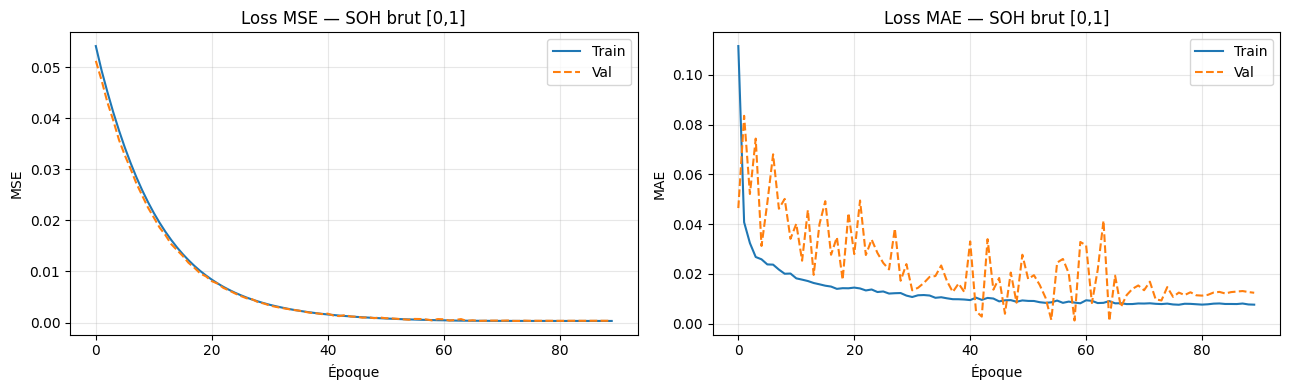

✅ loss_curves.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train', lw=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   lw=1.5, ls='--')
axes[0].set(xlabel='Époque', ylabel='MSE', title='Loss MSE — SOH brut [0,1]')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', lw=1.5)
axes[1].plot(history.history['val_mae'], label='Val',   lw=1.5, ls='--')
axes[1].set(xlabel='Époque', ylabel='MAE', title='Loss MAE — SOH brut [0,1]')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ loss_curves.png')

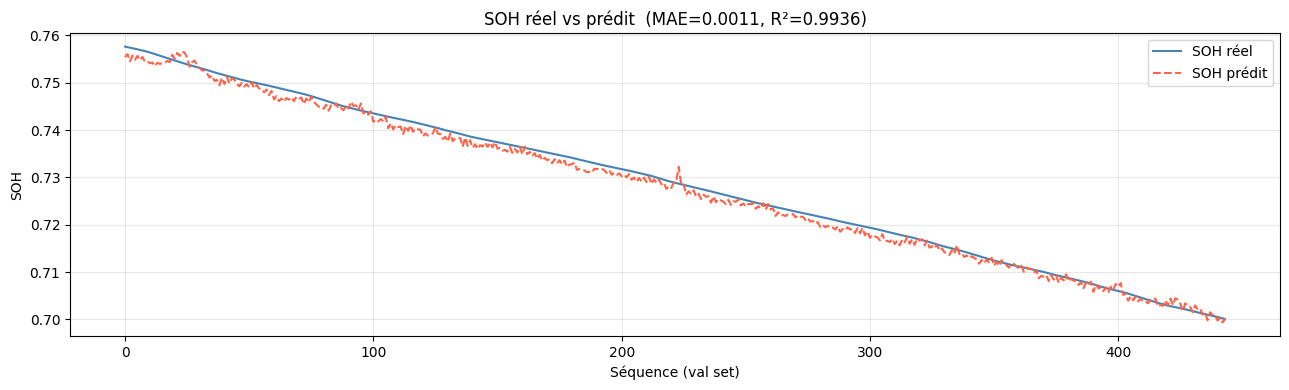

✅ soh_pred_vs_true.png


In [25]:
plt.figure(figsize=(13, 4))
plt.plot(soh_true, label='SOH réel',   lw=1.5, color='steelblue')
plt.plot(soh_pred, label='SOH prédit', lw=1.5, ls='--', color='tomato')
plt.xlabel('Séquence (val set)')
plt.ylabel('SOH')
plt.title(f'SOH réel vs prédit  (MAE={mae:.4f}, R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/soh_pred_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ soh_pred_vs_true.png')

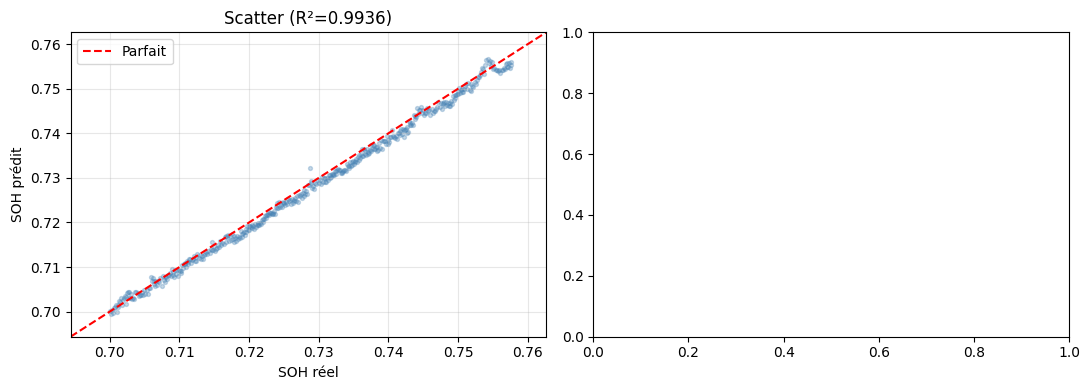

✅ scatter_residuals.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(soh_true, soh_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(soh_true.min(),soh_pred.min())-0.005, max(soh_true.max(),soh_pred.max())+0.005]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Parfait')
axes[0].set(xlim=lims, ylim=lims, xlabel='SOH réel', ylabel='SOH prédit',
            title=f'Scatter (R²={r2:.4f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = soh_pred - soh_true


plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/scatter_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ scatter_residuals.png')

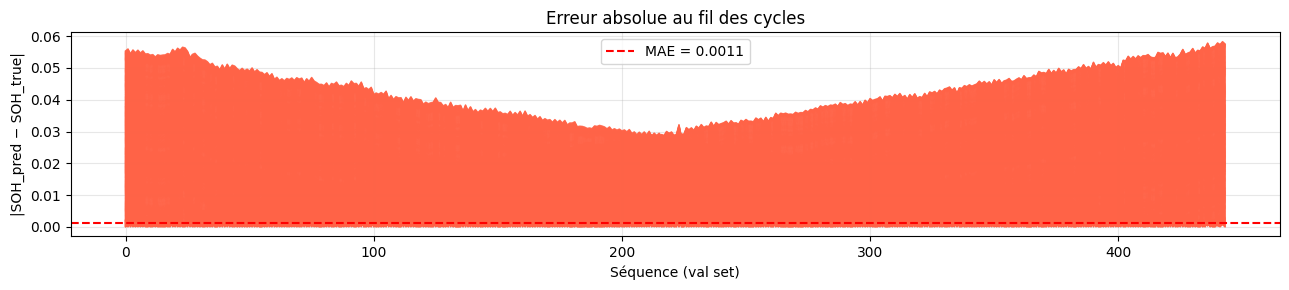

✅ abs_error.png


In [27]:
abs_err = np.abs(soh_pred - soh_true)
plt.figure(figsize=(13, 3))
plt.plot(abs_err, lw=1, color='tomato', alpha=0.8)
plt.axhline(mae, color='red', lw=1.5, ls='--', label=f'MAE = {mae:.4f}')
plt.xlabel('Séquence (val set)'); plt.ylabel('|SOH_pred − SOH_true|')
plt.title('Erreur absolue au fil des cycles')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/abs_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ abs_error.png')

## 15 — Sauvegarde

In [28]:
model.save(f'{OUTPUT_DIR}/cubesat_soh_lstm.keras')
joblib.dump(scaler_X, f'{OUTPUT_DIR}/scaler_X.pkl')
#joblib.dump(bias, f'{OUTPUT_DIR}/bias_correction.pkl')
with open(f'{OUTPUT_DIR}/features_used.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
pd.DataFrame([{
    'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'SMAPE': smape,
    'MedianAE': medae, 'MaxError': me, 'R2': r2, 'ExplainedVariance': evs,
    'target': 'SOH_raw', 'n_features': len(FEATURE_COLS),
    'window': WINDOW_SIZE, 'horizon': HORIZON,
    'train_cycles': len(train_df), 'val_cycles': len(val_df),
}]).to_csv(f'{OUTPUT_DIR}/metrics.csv', index=False)
print(f'✅ Artefacts → {OUTPUT_DIR}/')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {fn:<40} {os.path.getsize(f"{OUTPUT_DIR}/{fn}"):>10,} bytes')

✅ Artefacts → /content/drive/MyDrive/Colab Notebooks/outputs_1/
  abs_error.png                               100,348 bytes
  cubesat_soh_lstm.keras                    1,855,224 bytes
  features_used.pkl                               293 bytes
  loss_curves.png                              99,170 bytes
  metrics.csv                                     269 bytes
  scaler_X.pkl                                  1,623 bytes
  scatter_residuals.png                        79,521 bytes
  soh_pred_vs_true.png                         92,749 bytes
